# MFAA Chapter 17 Laboratory
**Portfolio Construction Suite** (book §17.10)

The book's cockpit: robust optimizer, pacing corridor, band-governance with the phantom-breach demonstration, liquidity budget, reverse-stress tilt finder. Seed `20261700`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch17
from dataclasses import replace

## 1. Frontiers: reported vs de-smoothed (Figure 17.1)
The de-smoothed frontier sits outside the reported one where private assets carry weight.

De-smoothing raises risk per unit return where the private asset matters — the misallocation the reported frontier hides.


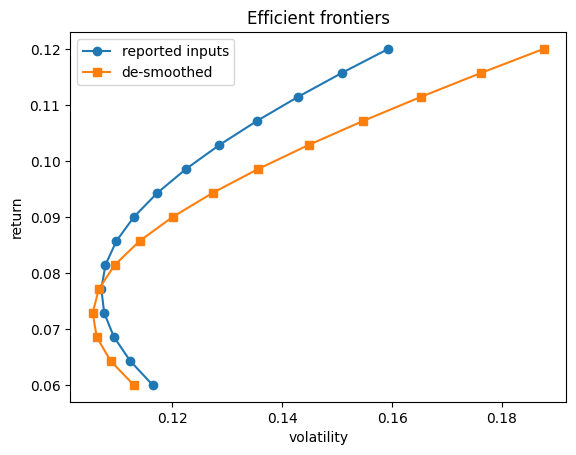

In [2]:
p = ch17.PortfolioParams()
fr = ch17.frontier(p, reported=True); fd = ch17.frontier(p, reported=False)
plt.plot(fr['vols'], fr['returns'], 'o-', label='reported inputs')
plt.plot(fd['vols'], fd['returns'], 's-', label='de-smoothed')
plt.xlabel('volatility'); plt.ylabel('return'); plt.legend(); plt.title('Efficient frontiers')
print('De-smoothing raises risk per unit return where the private asset matters — the misallocation the reported frontier hides.')

## 2. Ex 17.8 — The phantom breach (Proposition 17.5)
Reported deviation peaks at t* = log(κ/λ)/(κ-λ), strictly after the shock.

t* = 9.7 months (peak of reported breach)
true deviation at t*: 0.199 (~20% of peak)


Text(0.5, 1.0, 'The phantom breach: reported peak lags the true shock')

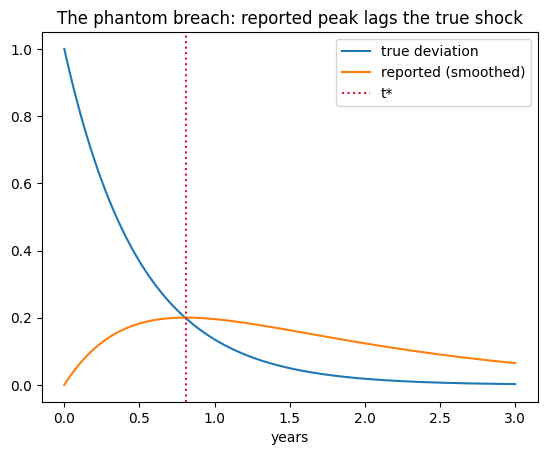

In [3]:
pb = ch17.phantom_breach(ch17.PortfolioParams(kappa=2.0, lam=0.7))
print(f"t* = {pb['t_star_months']:.1f} months (peak of reported breach)")
print(f"true deviation at t*: {pb['true_deviation_at_peak']:.3f} (~20% of peak)")
paths = ch17.phantom_breach_paths(ch17.PortfolioParams(kappa=2.0, lam=0.7))
plt.plot(paths['t'], paths['true'], label='true deviation')
plt.plot(paths['t'], paths['reported'], label='reported (smoothed)')
plt.axvline(pb['t_star_months']/12, color='crimson', ls=':', label='t*')
plt.legend(); plt.xlabel('years'); plt.title('The phantom breach: reported peak lags the true shock')

The band policy triggered on reported shares mandates its largest sales at the deepest discounts, against a breach that de-smoothed accounting shows to be resolving.

## 3. CVaR (Rockafellar-Uryasev) and the reverse-stress tilt

In [4]:
port = ch17.portfolio_scenarios(p, [0.4,0.3,0.3])
cv = ch17.cvar_rockafellar(-port, 0.95)
print(f"CVaR (LP): {cv['cvar']:.4f}, sample tail mean: {cv['tail_mean']:.4f}")
rs = ch17.reverse_stress_tilt(port, 0.05)
print(f"reverse-stress tilt: theta {rs['theta']:.3f}, entropy {rs['entropy']:.4f} (budget 0.05)")

CVaR (LP): 0.1484, sample tail mean: 0.1484
reverse-stress tilt: theta 0.369, entropy 0.0500 (budget 0.05)


## 4. Validation checks

In [5]:
v = ch17.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_cvar PASS
V2_entropic PASS
V3_tilt_budget PASS
V4_phantom_breach PASS
V5_frontier_order PASS
V6_reproducible PASS
ALL: True
